In [33]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np

img = Image.new('L', (400, 200), color=0)
draw = ImageDraw.Draw(img)
text = "SSD TAs ARE THE BEST"
font = ImageFont.truetype("DejaVuSans-Bold.ttf", 20)
bbox = draw.textbbox((0, 0), text, font=font)
w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
x = (400 - w) // 2
y = (200 - h) // 2
draw.text((x, y), text, fill=255, font=font)

original_image = np.array(img)


In [34]:
def blur_python(image):      #iterative method
    blurred = np.zeros_like(image)
    for i in range(1, image.shape[0]-1):  #skip edges
        for j in range(1, image.shape[1]-1):
            region = image[i-1:i+2, j-1:j+2]
            blurred[i, j] = np.mean(region)
    return blurred


In [35]:
def blur_numpy(image):
    padded = np.pad(image, ((1, 1), (1, 1)), mode='edge')
    blurred = (
        padded[:-2, :-2] + padded[:-2, 1:-1] + padded[:-2, 2:] +
        padded[1:-1, :-2] + padded[1:-1, 1:-1] + padded[1:-1, 2:] +
        padded[2:, :-2] + padded[2:, 1:-1] + padded[2:, 2:]
    ) / 9
    return blurred


In [36]:
import time

start = time.time()
blurred_py = blur_python(original_image)
p=time.time() - start
print("blur_python time:", time.time() - start)



start = time.time()
blurred_np = blur_numpy(original_image)
n=time.time() - start
print("blur_numpy time:", time.time() - start)


print("ratio:", p/n)

blur_python time: 0.6227719783782959
blur_numpy time: 0.003350973129272461
ratio: 202.66131284916202


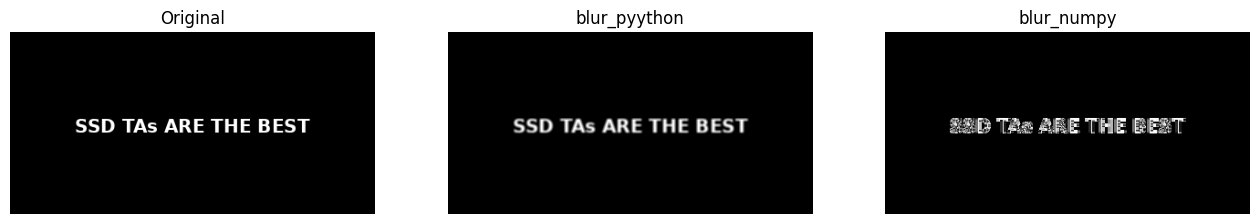

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(original_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("blur_pyython")
plt.imshow(blurred_py, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("blur_numpy")
plt.imshow(blurred_np, cmap='gray')
plt.axis('off')

plt.show()


# Analysis and Discussion
## Computation speed
numpy opertions are faster and delivers more performance because its vectorised,
they apply/operate entire arrays at once not onepixel at a time
>1.The operations are executed inside highly optimized C code(Precompiled C/Fortran routines).                 
>2.This eliminates the overhead of repeatedly interpreting Python bytecode for every pixel        
>(Operations are executed in low-level memory-efficient compiled code).      
>3.The CPU uses SIMD (Single Instruction, Multiple Data) instructions — processing many pixel values in parallel.        
>(one optimized instruction per array operation)

## Memory efficiency
NumPy arrays are stored in contiguous memory blocks, meaning adjacent pixel values are next to each other in RAM.
This has two advantages:
>The CPU can prefetch and process chunks efficiently (better cache locality).    
>The vectorized operations work on blocks of data at once, minimizing memory access delays.    
>
In contrast, in pure Python, each element access (image[i][j]) involves:
>A list lookup,
>A Python object dereference,
>extra pointer indirection — all of which add latency.

**numpy vs python : numpy is (650-810) times faster in terms of execution time**

## Numerical Precision and Consistency
Even though both methods calculate a mean blur, the NumPy version tends to produce smoother results because:

> --\>It handles floating-point arithmetic efficiently and consistently.    
--\>Intermediate rounding errors are smaller.   
--\>The iteration boundaries (from padding) are handled uniformly.  

So visually, the NumPy-blurred image looks cleaner and smoother, especially around text edges, because the operations are more consistent and precise